In [54]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [55]:
model = pd.read_csv('mall_customer_data.csv')
model

,customer_id,gender,age,payment_method,invoice_no,category,quantity,invoice date,price,shopping_mall,total_revenue,age_group,month,year
0,C241288,Female,28.0,Credit Card,I138884,Clothing,5,05/08/2022,1500.40,South Coast Plaza,7502.00,young,5,2022
1,C111565,Male,21.0,Debit Card,I317333,Shoes,3,12/12/2021,1800.51,Beverly Center,5401.53,young,12,2021
2,C266599,Male,20.0,Cash,I127801,Clothing,1,09/11/2021,300.08,Westfield Century City,300.08,young,9,2021
3,C988172,Female,66.0,Credit Card,I173702,Shoes,5,05/16/2021,3000.85,Stanford Shopping Center,15004.25,senior,5,2021
4,C189076,Female,53.0,Cash,I337046,Books,4,10/24/2021,60.60,South Coast Plaza,242.40,senior,10,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99452,C441542,Female,45.0,Credit Card,I219422,Souvenir,5,09/21/2022,58.65,South Coast Plaza,293.25,middle-aged,9,2022
99453,C569580,Male,27.0,Cash,I325143,Food & Beverage,2,09/22/2021,10.46,Beverly Center,20.92,young,9,2021
99454,C103292,Male,63.0,Debit Card,I824010,Food & Beverage,2,03/28/2021,10.46,Westfield Century City,20.92,senior,3,2021
99455,C800631,Male,56.0,Cash,I702964,Technology,4,03/16/2021,4200.00,Westfield Valley Fair,16800.00,senior,3,2021


In [56]:
model_df = model.groupby('customer_id').agg(
    age=('age', 'mean'),
    total_quantity=('quantity', 'sum'),
    total_revenue=('total_revenue', 'sum')
).reset_index()

In [57]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(model_df[['age', 'total_quantity' , 'total_revenue']])


In [58]:
wcss = []
for i in range(1 ,11):
    km = KMeans(n_clusters =i , random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

In [59]:
import matplotlib.pyplot as plt

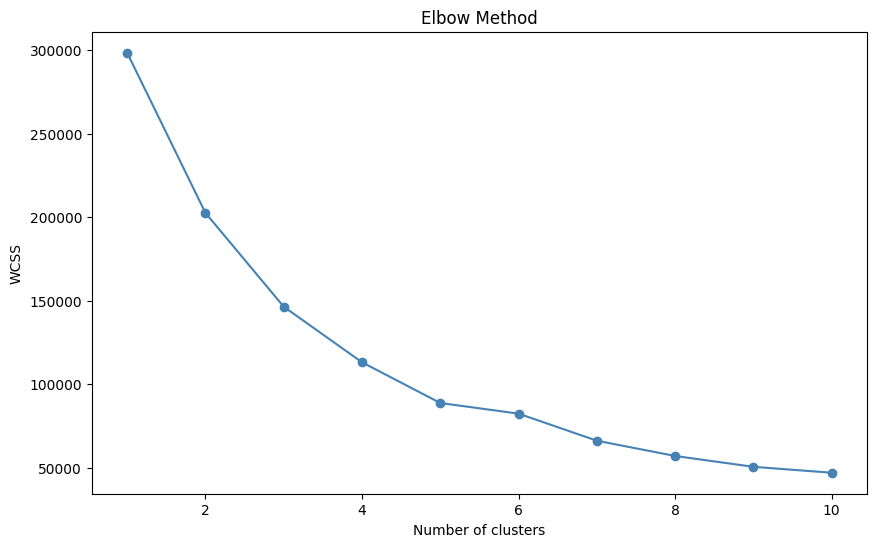

In [60]:
plt.figure(figsize=(10,6))
plt.plot(range(1,11), wcss , marker='o' , color ='steelblue')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [61]:
kmeans = KMeans(n_clusters = 4 , random_state =42)
model_df['cluster'] = kmeans.fit_predict(X_scaled)
model_df

,customer_id,age,total_quantity,total_revenue,cluster
0,C100004,61.0,5,7502.00,3
1,C100005,34.0,2,2400.68,1
2,C100006,44.0,3,322.56,1
3,C100012,25.0,5,130.75,1
4,C100019,21.0,1,35.84,1
...,...,...,...,...,...
99452,C999886,61.0,3,47.07,0
99453,C999910,41.0,3,136.35,1
99454,C999974,29.0,5,7502.00,2
99455,C999976,49.0,3,322.56,0


In [63]:
clusters_summary = model_df.groupby('cluster')['total_revenue'].mean()
revenue_rank = clusters_summary.sort_values(ascending=False).index.tolist()

In [64]:
labels = ['VIP / High Spender' , 'Regular Buyer' , 'Occasional Buyer' , 'Low Spender']
label_map = {cluster: label for cluster , label in zip(revenue_rank , labels)}
model_df['segment'] = model_df['cluster'].map(label_map)

In [65]:
print("\nSegmentation Summary:")
print(model_df['segment'].value_counts())


Segmentation Summary:
segment
Occasional Buyer      33835
Low Spender           29474
Regular Buyer         24563
VIP / High Spender    11585
Name: count, dtype: int64


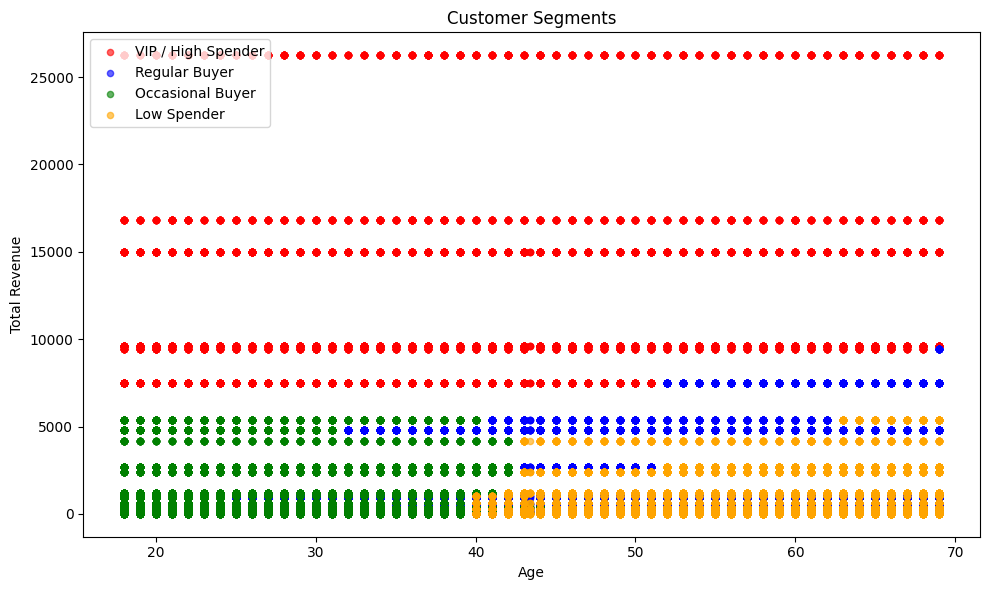

In [66]:
colors = ['red', 'blue', 'green', 'orange']
plt.figure(figsize=(10,6))
for i , (cid , label) in enumerate(label_map.items()):
    subset = model_df[model_df['cluster'] == cid]
    plt.scatter(subset['age'] , subset['total_revenue'] , label=label , color=colors[i] ,
                 alpha=0.6 , s=20)
    
plt.title('Customer Segments')
plt.xlabel('Age')
plt.ylabel('Total Revenue')
plt.legend()
plt.tight_layout()
plt.show()    

In [67]:
model_df.to_csv('customer_segments.csv' , index=False)